<a href="https://colab.research.google.com/github/aiska28/Data-Maining/blob/main/jb11_tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load data
df = pd.read_csv(
    '/content/drive/MyDrive/kuliah/Data_Mining/Iris.csv',
    sep=';'
)
# Tampilkan 5 data pertama
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [5]:
# Ambil fitur saja
X = df.iloc[:, 1:5]

# Nama fitur
fitur = X.columns

# Tampilkan fitur
print(X.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

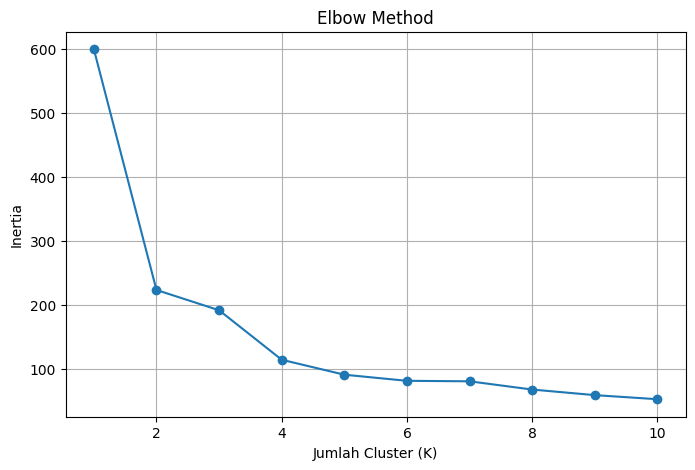

In [8]:
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [9]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.5802
K = 3, Silhouette Score = 0.4787
K = 4, Silhouette Score = 0.3872
K = 5, Silhouette Score = 0.3473
K = 6, Silhouette Score = 0.3362
K = 7, Silhouette Score = 0.2686
K = 8, Silhouette Score = 0.3157
K = 9, Silhouette Score = 0.2991
K = 10, Silhouette Score = 0.3211


In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

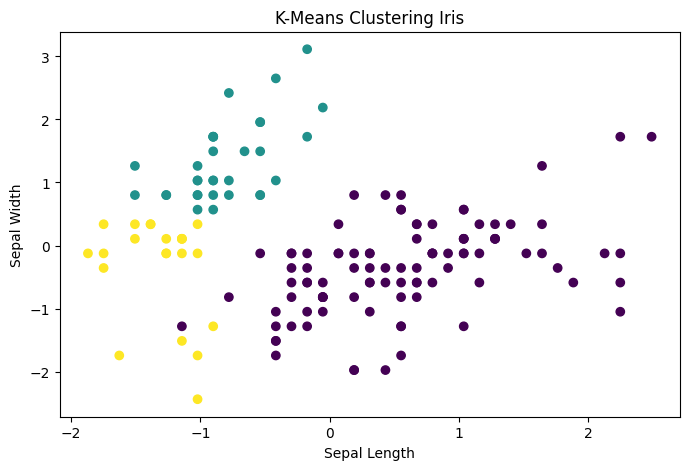

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    cmap='viridis'
)

plt.title('K-Means Clustering Iris')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

plt.show()

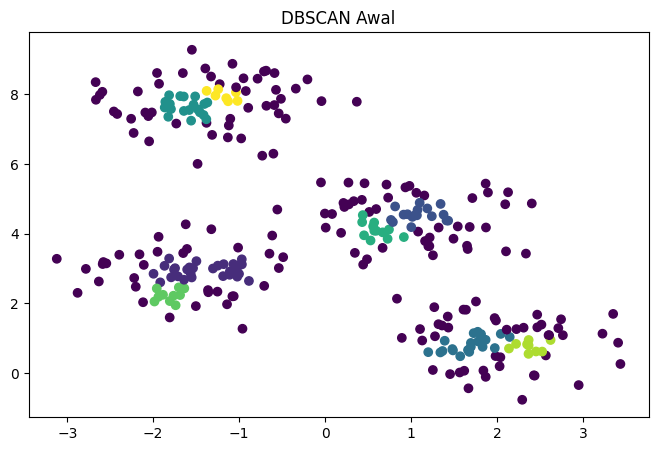

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

# Membuat data contoh
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0
)

dbscan = DBSCAN(
    eps=0.3,
    min_samples=10
)

labels = dbscan.fit_predict(X)

plt.figure(figsize=(8,5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap='viridis'
)

plt.title("DBSCAN Awal")
plt.show()

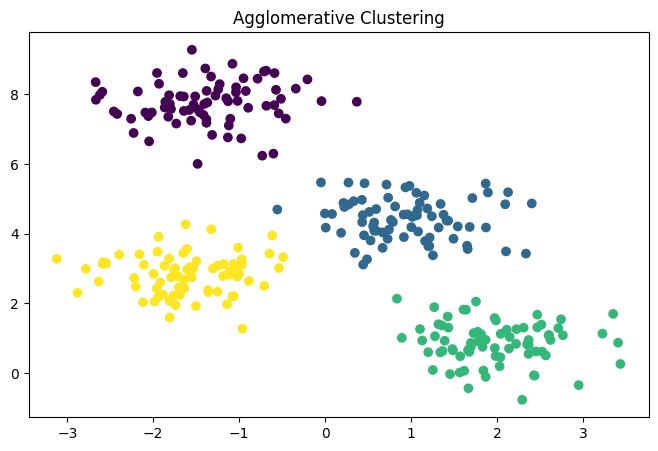

In [17]:
agglo = AgglomerativeClustering(
    n_clusters=4
)

labels_agglo = agglo.fit_predict(X)

plt.figure(figsize=(8,5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_agglo,
    cmap='viridis'
)

plt.title("Agglomerative Clustering")
plt.show()

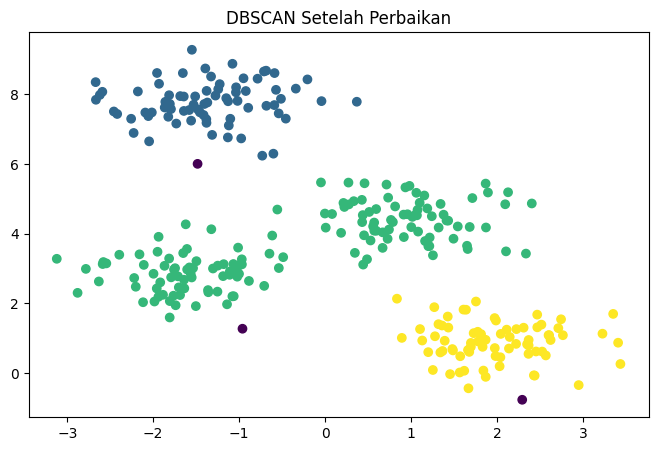

In [18]:
dbscan_baik = DBSCAN(
    eps=0.7,
    min_samples=4
)

labels_baik = dbscan_baik.fit_predict(X)

plt.figure(figsize=(8,5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_baik,
    cmap='viridis'
)

plt.title("DBSCAN Setelah Perbaikan")
plt.show()